# pybenford — Full Workflow Demo

This notebook walks through every test in the `pybenford` package using US Census county population data (3,195 counties, 2025 estimates).

Population figures are a textbook Benford-conforming dataset: they span several orders of magnitude and arise from natural growth processes. This makes them a good baseline for verifying that the tests work correctly — you should see close conformity across most tests.

## Setup

In [1]:
import pandas as pd
import numpy as np
from pybenford import BenfordAnalysis
from pybenford.visualization import (
    plot_digit_test,
    plot_summation,
    plot_z_scores,
    plot_mantissa_arc,
    plot_ordered_mantissas,
    plot_distortion_factor,
)

%matplotlib inline

## Load Data

In [2]:
df = pd.read_csv("data/co-est2025-alldata.csv", encoding="latin-1")
print(f"Rows: {len(df):,}")
print(f"Column: POPESTIMATE2025")
print(f"Range: {df['POPESTIMATE2025'].min():,} to {df['POPESTIMATE2025'].max():,}")
print(f"Orders of magnitude: {np.log10(df['POPESTIMATE2025'].max()) - np.log10(df['POPESTIMATE2025'].clip(lower=1).min()):.1f}")

Rows: 3,195
Column: POPESTIMATE2025
Range: 52 to 39,355,309
Orders of magnitude: 5.9


## Create the Analysis Object

Pass any numeric sequence — list, numpy array, or pandas/polars Series. Data cleaning (removing NaN, Inf, zeros, applying sign filters) happens automatically.

In [3]:
analysis = BenfordAnalysis(df["POPESTIMATE2025"])
print(analysis.profile)

DataProfile(total_count=3195, strata=(Stratum(name='Large positive', count=3195, total_sum=683569714.0, percentage=100.0), Stratum(name='Small positive', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Zero', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Small negative', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Large negative', count=0, total_sum=0.0, percentage=0.0)), invalid_count=0)


## First Digit Test

The starting point for any Benford analysis. Compares the frequency of leading digits (1-9) against the expected Benford distribution. Nine bins, so results are easy to interpret visually.

In [4]:
result_d1 = analysis.first_digit()
print(result_d1)

  First Digit Test  (n=3,195  alpha=0.05)
 Digit   Count   Observed   Expected   Z-Score   Sig
     1    956   29.92%    30.10%      0.20
     2    595   18.62%    17.61%      1.48
     3    389   12.18%    12.49%      0.52
     4    299    9.36%     9.69%      0.61
     5    255    7.98%     7.92%      0.10
     6    197    6.17%     6.69%      1.16
     7    180    5.63%     5.80%      0.36
     8    171    5.35%     5.12%      0.57
     9    153    4.79%     4.58%      0.53
-------------------------------------------------------
 MAD:        0.0034 — Close Conformity
 Chi-Square: 4.6922  (critical: 15.5073) — Pass
 KS:         0.0083  (critical: 0.0240)  — Pass


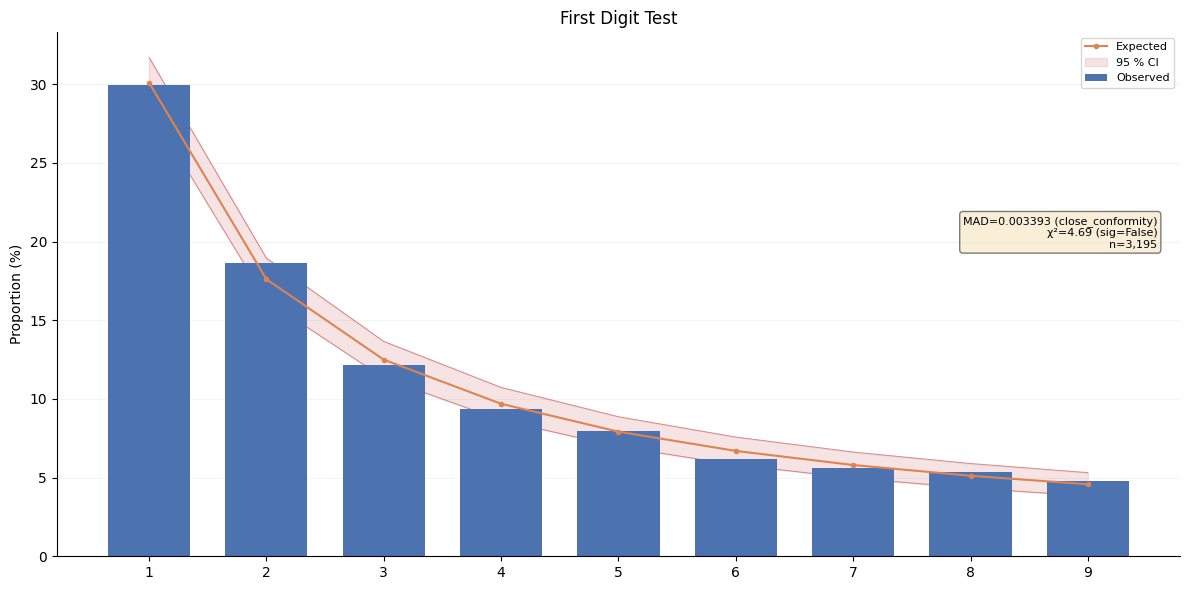

In [5]:
fig, ax = plot_digit_test(result_d1, show_confidence=True)

## Second Digit Test

Tests the second significant digit (0-9). Less well known than the first digit test but still useful. The expected distribution is flatter than the first digit — digit 0 is most common at ~12%, digit 9 least at ~8.5%.

In [6]:
result_d2 = analysis.second_digit()
print(result_d2)

  Second Digit Test  (n=3,195  alpha=0.05)
 Digit   Count   Observed   Expected   Z-Score   Sig
     0    378   11.83%    11.97%      0.21
     1    359   11.24%    11.39%      0.24
     2    328   10.27%    10.88%      1.09
     3    321   10.05%    10.43%      0.68
     4    320   10.02%    10.03%      0.00
     5    308    9.64%     9.67%      0.02
     6    335   10.49%     9.34%      2.20  *
     7    293    9.17%     9.04%      0.24
     8    309    9.67%     8.76%      1.80
     9    244    7.64%     8.50%      1.72
-------------------------------------------------------
 MAD:        0.0044 — Close Conformity
 Chi-Square: 12.1097  (critical: 16.9190) — Pass
 KS:         0.0133  (critical: 0.0240)  — Pass


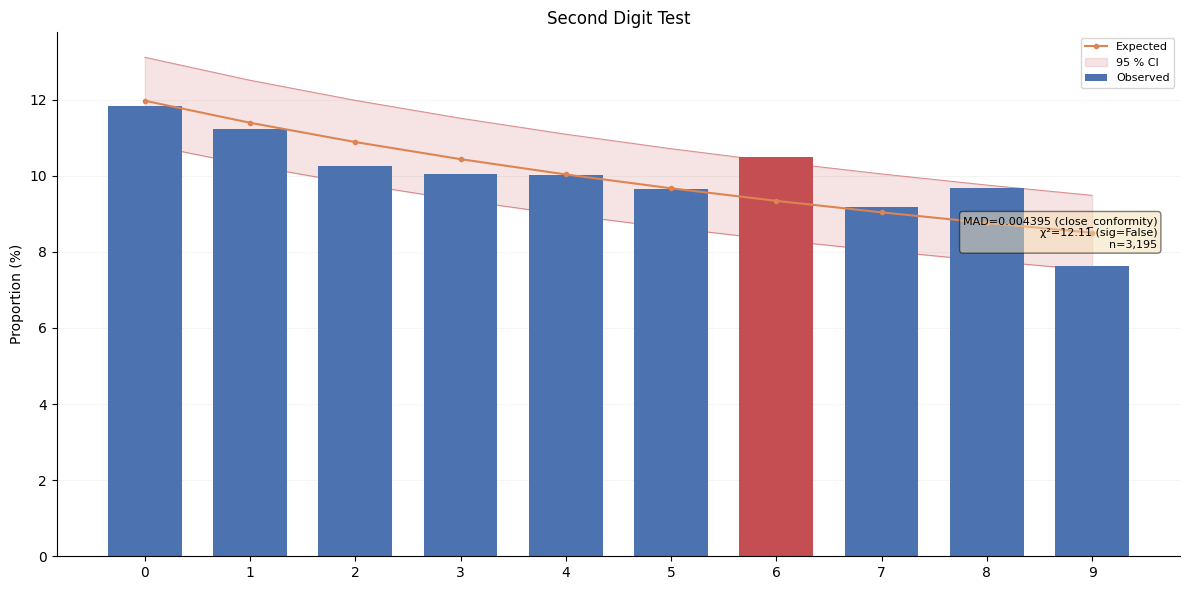

In [7]:
fig, ax = plot_digit_test(result_d2, show_confidence=True)

## First Two Digits Test

The workhorse of forensic Benford analysis (Nigrini Ch. 5). Tests 90 digit combinations (10-99) against expected Benford proportions. With more bins, this test is more sensitive to localized anomalies than the first digit test alone.

The formatted output automatically shows only flagged digits when there are more than 10 bins.

In [8]:
result_d12 = analysis.first_two_digits()
print(result_d12)

  First Two Digits Test  (n=3,195  alpha=0.05)
 Flagged Digits (7 of 90):
 Digit   Count   Observed   Expected   Z-Score
    35     24    0.75%     1.22%      2.35  *
    49     16    0.50%     0.88%      2.19  *
    66     33    1.03%     0.65%      2.56  *
    70     29    0.91%     0.62%      1.99  *
    75     28    0.88%     0.58%      2.13  *
    76      9    0.28%     0.57%      2.03  *
    77      9    0.28%     0.56%      1.99  *
-------------------------------------------------------
 MAD:        0.0015 — Acceptable Conformity
 Chi-Square: 104.9157  (critical: 112.0220) — Pass
 KS:         0.0102  (critical: 0.0240)  — Pass


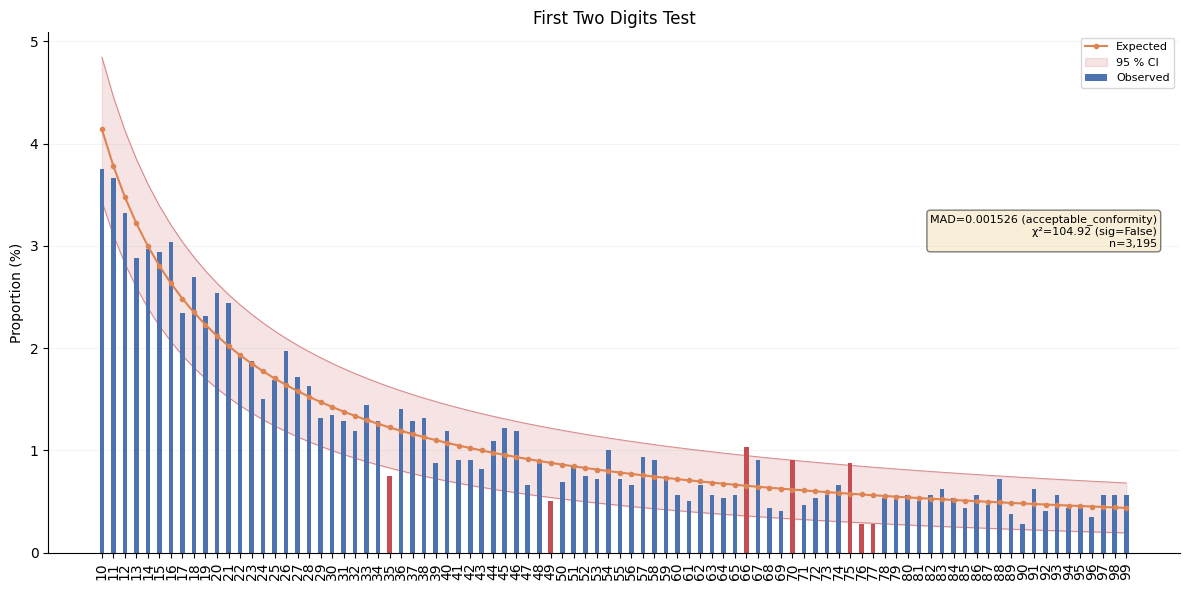

In [9]:
fig, ax = plot_digit_test(result_d12, show_confidence=True)

## First Three Digits Test

900 bins (100-999). Requires a large dataset to be meaningful — with n=3,195 the average expected count per bin is only ~3.5, which pushes chi-square into unreliable territory. Useful for very large datasets (n > 50,000).

In [10]:
result_d123 = analysis.first_three_digits()
print(result_d123)

  First Three Digits Test  (n=3,195  alpha=0.05)
 Flagged Digits (25 of 900):
 Digit   Count   Observed   Expected   Z-Score
   118     20    0.63%     0.37%      2.28  *
   157     21    0.66%     0.28%      3.94  *
   178     15    0.47%     0.24%      2.42  *
   216     12    0.38%     0.20%      2.01  *
   237     12    0.38%     0.18%      2.34  *
   269      0    0.00%     0.16%      2.05  *
   278     10    0.31%     0.16%      2.03  *
   378      9    0.28%     0.11%      2.53  *
   442      8    0.25%     0.10%      2.47  *
   455      7    0.22%     0.10%      1.98  *
   458      7    0.22%     0.09%      2.00  *
   463      7    0.22%     0.09%      2.03  *
   570      6    0.19%     0.08%      1.97  *
   573      7    0.22%     0.08%      2.62  *
   601      7    0.22%     0.07%      2.76  *
   702      7    0.22%     0.06%      3.22  *
   740      6    0.19%     0.06%      2.65  *
   753      7    0.22%     0.06%      3.43  *
   759      6    0.19%     0.06%      2.72  *
 

## Last Two Digits Test

Tests the last two digits (00-99) against a uniform distribution (each combination expected at 1%). This is not a Benford test per se — it detects rounding, truncation, and number invention. Fabricated data often has excess 00s and 50s.

In [11]:
result_last2 = analysis.last_two_digits()
print(result_last2)

  Last Two Digits Test  (n=3,195  alpha=0.05)
 Flagged Digits (5 of 100):
 Digit   Count   Observed   Expected   Z-Score
    20     44    1.38%     1.00%      2.05  *
    32     44    1.38%     1.00%      2.05  *
    35     19    0.59%     1.00%      2.21  *
    50     19    0.59%     1.00%      2.21  *
    88     49    1.53%     1.00%      2.94  *
-------------------------------------------------------
 MAD:        0.0015 — N/A (no threshold defined)
 Chi-Square: 103.2473  (critical: 123.2252) — Pass
 KS:         0.0073  (critical: 0.0240)  — Pass


## Second Order Test

Sorts the data, computes successive differences, and runs a digit test on those differences (Nigrini Ch. 6). The differences of a Benford-conforming dataset should themselves follow Benford's Law.

This test has very few false positives. If it flags nonconformity, something unusual is happening in the data.

In [12]:
result_so = analysis.second_order()
print(result_so)

  Second Order Test  (n=3,141  alpha=0.05)
 Flagged Digits (43 of 90):
 Digit   Count   Observed   Expected   Z-Score
    10    233    7.42%     4.14%      9.18  *
    11     96    3.06%     3.78%      2.08  *
    20    163    5.19%     2.12%     11.89  *
    26     35    1.11%     1.64%      2.25  *
    27     33    1.05%     1.58%      2.31  *
    29     32    1.02%     1.47%      2.04  *
    30    129    4.11%     1.42%     12.62  *
    40    116    3.69%     1.07%     14.17  *
    43     19    0.60%     1.00%      2.13  *
    44     17    0.54%     0.98%      2.39  *
    48     16    0.51%     0.90%      2.20  *
    49     11    0.35%     0.88%      3.07  *
    50     96    3.06%     0.86%     13.23  *
    52     12    0.38%     0.83%      2.66  *
    53     13    0.41%     0.81%      2.39  *
    55      8    0.25%     0.78%      3.26  *
    56     10    0.32%     0.77%      2.79  *
    57      8    0.25%     0.76%      3.14  *
    58     11    0.35%     0.74%      2.46  *
    59  

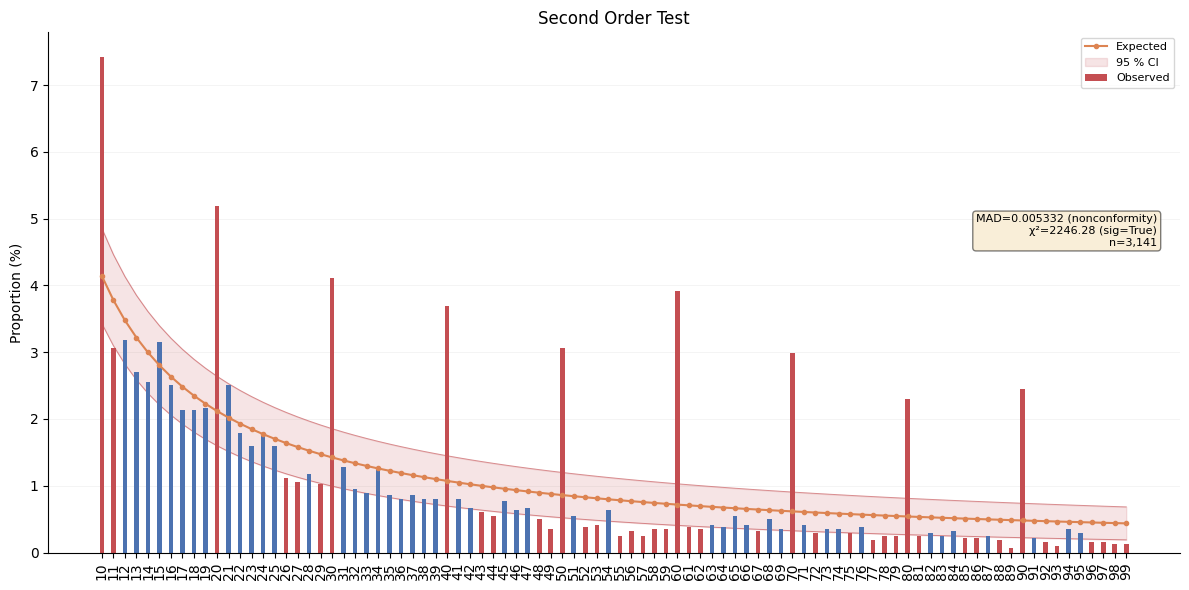

In [13]:
fig, ax = plot_digit_test(result_so, show_confidence=True)

## Summation Test

Groups values by their first two digits (10-99) and computes the sum of each group as a proportion of the total. Under Benford's Law, each group should contribute approximately 1/90 (~1.11%) of the total sum.

Spikes indicate either a few very large values or clusters of repeated medium-sized values sharing the same leading digits. This is the test that catches individually large outliers.

In [14]:
result_sum = analysis.summation()
print(result_sum)

  Summation Test  (n=3,195  alpha=0.05)
 Grand Sum: 683,569,714

 Flagged Digits (65 of 90):
 Digit         Sum   Observed   Expected   Z-Score
    10  24,716,820    3.62%     1.11%     13.42  *
    11  44,326,134    6.48%     1.11%     28.89  *
    12  27,395,821    4.01%     1.11%     15.54  *
    13  21,453,409    3.14%     1.11%     10.85  *
    15  12,629,719    1.85%     1.11%      3.89  *
    16  11,689,418    1.71%     1.11%      3.15  *
    18   4,077,778    0.60%     1.11%      2.69  *
    20  30,498,566    4.46%     1.11%     17.98  *
    23  31,136,239    4.55%     1.11%     18.49  *
    27   4,741,424    0.69%     1.11%      2.17  *
    30   3,369,344    0.49%     1.11%      3.25  *
    31  40,275,378    5.89%     1.11%     25.70  *
    32  12,759,656    1.87%     1.11%      3.99  *
    33   3,473,500    0.51%     1.11%      3.17  *
    34   2,380,869    0.35%     1.11%      4.03  *
    37   2,918,776    0.43%     1.11%      3.60  *
    38   3,854,643    0.56%     1.11%   

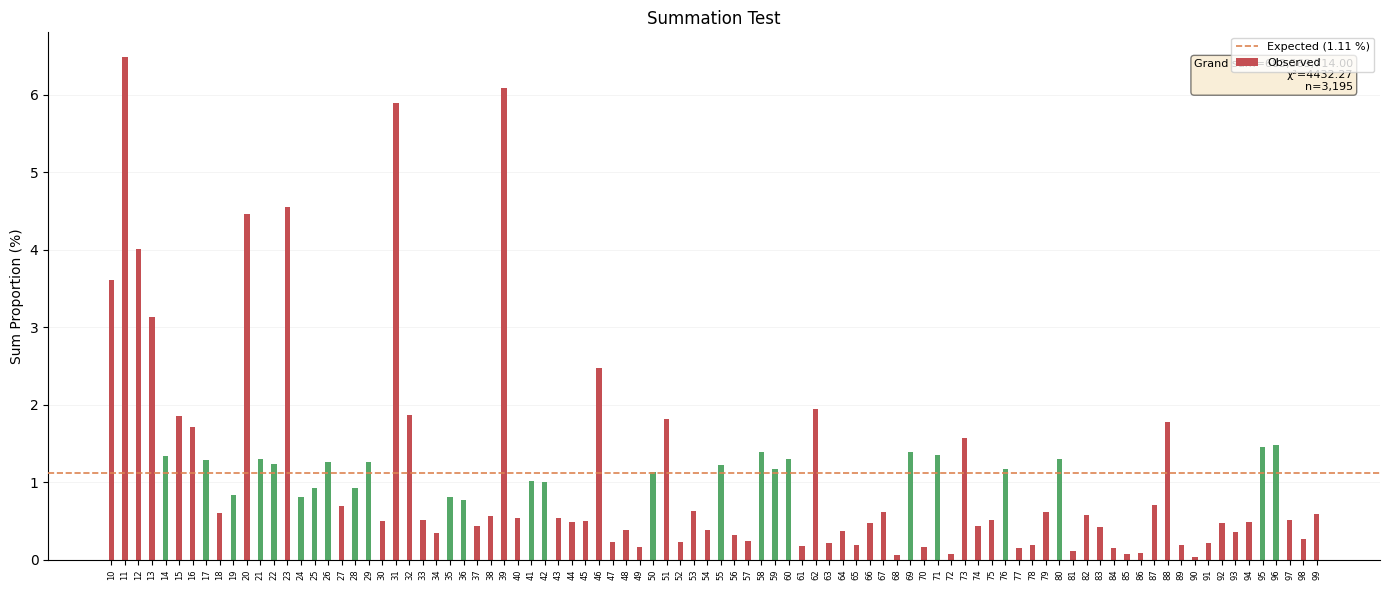

In [15]:
fig, ax = plot_summation(result_sum)

## Distortion Factor

Quantifies systematic over- or understatement (Nigrini Ch. 6). Each value is collapsed to the range [10, 100) and the mean of these collapsed values is compared against the theoretical Benford mean of 39.0865.

A positive distortion factor indicates overstatement (values are systematically larger than expected); negative indicates understatement. The Z-test tells you whether the deviation is statistically significant.

In [16]:
result_df = analysis.distortion_factor()
print(result_df)

  Distortion Factor Test
 Distortion Factor:  -0.0006 (Understated)
 Actual Mean:         39.0632
 Expected Mean:       39.0865
 Z-Statistic:         -0.0528  (p=0.9579)
 Significant:         No


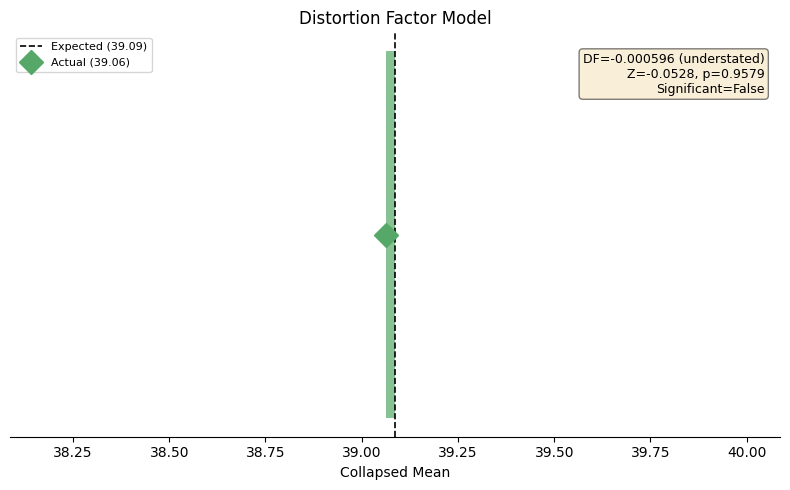

In [17]:
fig, ax = plot_distortion_factor(result_df)

## Mantissa Arc Test

Tests whether the mantissas (fractional part of log10 values) are uniformly distributed on [0, 1) (Nigrini Ch. 7, Alexander 2009).

Each mantissa is mapped to a point on the unit circle. If the data conforms to Benford's Law, these points should be uniformly distributed around the circle, with the center of gravity near the origin (0, 0). The L-squared statistic measures how far the center of gravity deviates from (0, 0).

In [18]:
result_ma = analysis.mantissa_arc()
print(result_ma)

  Mantissa Arc Test
 Gravity Center:  (-0.0072, 0.0191)
 L2 Statistic:     0.0204
 Mean Angle:        3.1415 rad  (180.00 deg)
 P-Value:           0.2653


In [ ]:
fig, ax = plot_mantissa_arc(result_ma)

In [ ]:
fig, ax = plot_ordered_mantissas(result_ma)

## Number Duplication

Lists the most frequently repeated values in the dataset (Nigrini Ch. 5). This is the drill-down test — once you've identified suspicious digit patterns via the first-two digits or summation tests, number duplication tells you which specific values are driving those patterns.

In forensic contexts, excessively duplicated values near approval thresholds (e.g., many invoices at $4,999 just below a $5,000 approval limit) are a classic fraud indicator.

In [21]:
result_dup = analysis.number_duplication(top_n=20)
print(result_dup)

  Number Duplication Test
 Total Records: 3,195  |  Unique Values: 3,142

 Top Duplicated Values:
  Value       Count   First-Two
     693,645          2           69
      74,967          2           74
      54,037          2           54
      41,853          2           41
      40,083          2           40
      33,894          2           33
      33,322          2           33
      32,515          2           32
      31,171          2           31
      27,983          2           27
      26,799          2           26
      26,410          2           26
      25,684          2           25
      25,517          2           25
      23,951          2           23
      22,671          2           22
      20,831          2           20
      20,322          2           20
      20,118          2           20
      18,110          2           18


## Working with Results Programmatically

Every result object exposes its data as attributes. This is useful when you need to feed results into downstream analysis or build custom reports.

In [22]:
result = analysis.first_digit()

print(f"Test:            {result.test_name}")
print(f"Records:         {result.n:,}")
print(f"Alpha:           {result.alpha}")
print(f"MAD:             {result.mad:.6f}")
print(f"MAD Conformity:  {result.mad_conformity}")
print(f"Chi-Square:      {result.chi_square:.4f} (critical: {result.chi_square_critical:.4f})")
print(f"Chi-Square Sig:  {result.chi_square_significant}")
print(f"KS Statistic:    {result.ks_statistic:.4f} (critical: {result.ks_critical:.4f})")
print(f"KS Significant:  {result.ks_significant}")

Test:            first_digit
Records:         3,195
Alpha:           0.05
MAD:             0.003393
MAD Conformity:  close_conformity
Chi-Square:      4.6922 (critical: 15.5073)
Chi-Square Sig:  False
KS Statistic:    0.0083 (critical: 0.0240)
KS Significant:  False


In [23]:
# Per-digit breakdown as a DataFrame
digit_df = pd.DataFrame({
    "digit": result.digits,
    "count": result.counts,
    "observed": result.observed,
    "expected": result.expected,
    "z_score": result.z_scores,
    "significant": result.significant_flags,
})
digit_df

,digit,count,observed,expected,z_score,significant
0,1,956,0.299218,0.301030,0.204059,False
1,2,595,0.186228,0.176091,1.481116,False
2,3,389,0.121753,0.124939,0.517892,False
3,4,299,0.093584,0.096910,0.605643,False
4,5,255,0.079812,0.079181,0.099321,False
5,6,197,0.061659,0.066947,1.160534,False
6,7,180,0.056338,0.057992,0.362134,False
7,8,171,0.053521,0.051153,0.567558,False
8,9,153,0.047887,0.045757,0.533798,False


## Z-Score Visualization

A dedicated Z-score plot shows which digits deviate most from the expected Benford distribution. The dashed lines mark the critical value at the chosen alpha.

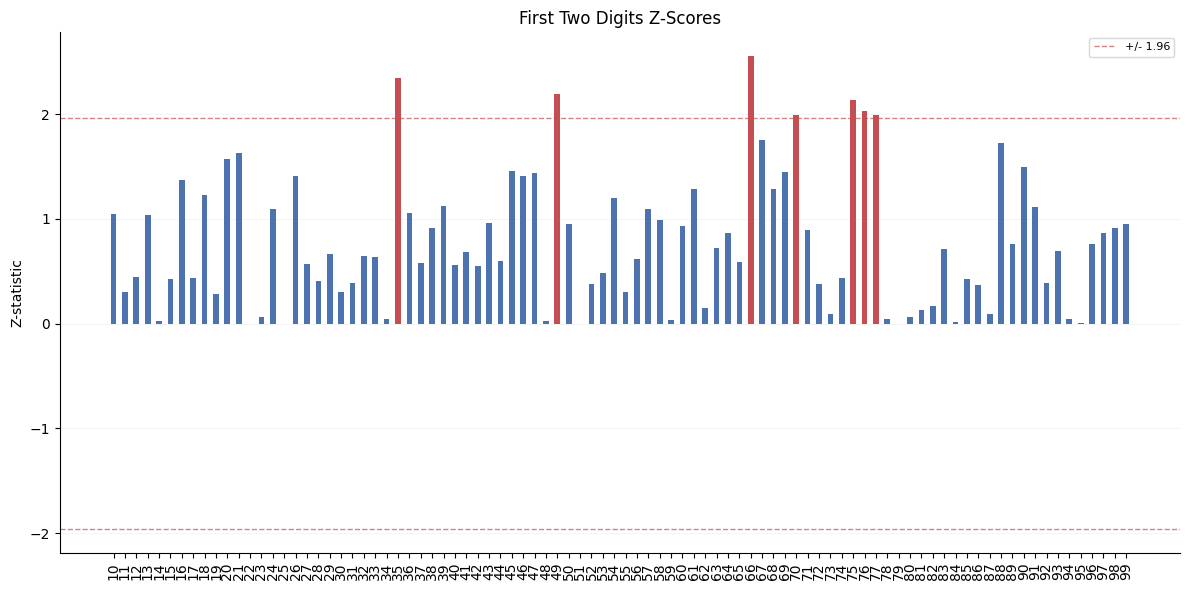

In [24]:
fig, ax = plot_z_scores(result_d12)

## Using sign_filter for Forensic Workflows

In forensic accounting, income and expense items should be analyzed separately. The `sign_filter` parameter handles this. Here we simulate a mixed dataset to demonstrate.

In [25]:
# Simulate a mixed income/expense dataset
np.random.seed(42)
mixed_data = np.concatenate([
    np.random.lognormal(mean=8, sigma=1.5, size=3000),   # income (positive)
    -np.random.lognormal(mean=7, sigma=1.2, size=2000),  # expenses (negative)
])

# Analyze positive values only (income)
income_analysis = BenfordAnalysis(mixed_data, sign_filter="positive")
print(f"Income records: {income_analysis.profile}")
print(income_analysis.first_digit())

print("\n")

# Analyze negative values only (expenses)
expense_analysis = BenfordAnalysis(mixed_data, sign_filter="negative")
print(f"Expense records: {expense_analysis.profile}")
print(expense_analysis.first_digit())

Income records: DataProfile(total_count=5000, strata=(Stratum(name='Large positive', count=3000, total_sum=29456005.23946987, percentage=60.0), Stratum(name='Small positive', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Zero', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Small negative', count=0, total_sum=0.0, percentage=0.0), Stratum(name='Large negative', count=2000, total_sum=-4282481.225687349, percentage=40.0)), invalid_count=0)
  First Digit Test  (n=3,000  alpha=0.05)
 Digit   Count   Observed   Expected   Z-Score   Sig
     1    894   29.80%    30.10%      0.34
     2    525   17.50%    17.61%      0.13
     3    376   12.53%    12.49%      0.04
     4    306   10.20%     9.69%      0.91
     5    228    7.60%     7.92%      0.61
     6    223    7.43%     6.69%      1.58
     7    187    6.23%     5.80%      0.98
     8    147    4.90%     5.12%      0.49
     9    114    3.80%     4.58%      1.99  *
-------------------------------------------------------
